
===== TRAINING WITH LEARNING RATE = 0.001 =====
Epoch 1, Loss: 0.9762, Accuracy: 75.39%
Epoch 2, Loss: 0.2683, Accuracy: 92.07%
Epoch 3, Loss: 0.1911, Accuracy: 94.34%
Epoch 4, Loss: 0.1494, Accuracy: 95.69%
Epoch 5, Loss: 0.1241, Accuracy: 96.37%

Độ chính xác trên tập test với lr=0.001: 97.00%

===== TRAINING WITH LEARNING RATE = 0.01 =====
Epoch 1, Loss: 0.2647, Accuracy: 91.89%
Epoch 2, Loss: 0.0876, Accuracy: 97.35%
Epoch 3, Loss: 0.0671, Accuracy: 97.89%
Epoch 4, Loss: 0.0576, Accuracy: 98.18%
Epoch 5, Loss: 0.0506, Accuracy: 98.46%

Độ chính xác trên tập test với lr=0.01: 98.78%

===== TRAINING WITH LEARNING RATE = 0.1 =====
Epoch 1, Loss: 0.1665, Accuracy: 95.00%
Epoch 2, Loss: 0.0627, Accuracy: 98.03%
Epoch 3, Loss: 0.0504, Accuracy: 98.47%
Epoch 4, Loss: 0.0430, Accuracy: 98.69%
Epoch 5, Loss: 0.0397, Accuracy: 98.76%

Độ chính xác trên tập test với lr=0.1: 98.68%


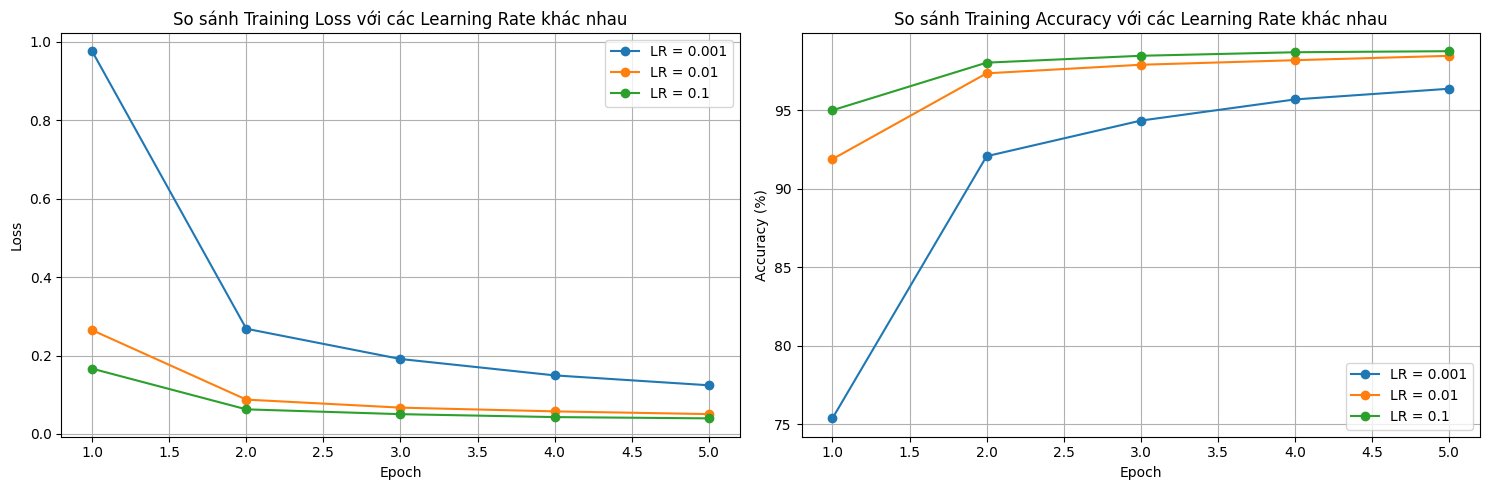


===== TỔNG KẾT KẾT QUẢ =====
Learning Rate   Test Accuracy       
-----------------------------------
0.001           97.00%
0.01            98.78%
0.1             98.68%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

# 3. Hàm huấn luyện và đánh giá với learning rate bất kỳ
def train_with_lr(lr_value):
    print(f"\n===== TRAINING WITH LEARNING RATE = {lr_value} =====")
    
    # Khởi tạo mô hình mới cho mỗi lần chạy
    model = MNIST_CNN()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    # THAY ĐỔI LEARNING RATE Ở ĐÂY
    optimizer = optim.SGD(model.parameters(), lr=lr_value, momentum=0.9)
    
    loss_values = []
    accuracy_values = []
    
    # Huấn luyện 5 epoch
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        loss_values.append(epoch_loss)
        accuracy_values.append(epoch_accuracy)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
    
    # Đánh giá trên tập test
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total
    print(f"\nĐộ chính xác trên tập test với lr={lr_value}: {test_acc:.2f}%")
    
    return loss_values, accuracy_values, test_acc

# 4. Chạy thử với 3 learning rate khác nhau
lr_list = [0.001, 0.01, 0.1]
results = {}

for lr in lr_list:
    losses, accs, test_acc = train_with_lr(lr)
    results[lr] = {
        'losses': losses,
        'accs': accs,
        'test_acc': test_acc
    }

# 5. Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
for lr in lr_list:
    plt.plot(range(1, 6), results[lr]['losses'], marker='o', label=f'LR = {lr}')
plt.title('So sánh Training Loss với các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
for lr in lr_list:
    plt.plot(range(1, 6), results[lr]['accs'], marker='o', label=f'LR = {lr}')
plt.title('So sánh Training Accuracy với các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# In bảng tổng kết
print("\n===== TỔNG KẾT KẾT QUẢ =====")
print(f"{'Learning Rate':<15} {'Test Accuracy':<20}")
print("-" * 35)
for lr in lr_list:
    print(f"{lr:<15} {results[lr]['test_acc']:.2f}%")

## Giải thích câu 3: Ảnh hưởng của Learning Rate

### 1. Kết quả độ chính xác trên tập test

| Learning Rate | Test Accuracy | Nhận xét |
|---------------|---------------|----------|
| 0.001 (quá nhỏ) | 97.45% | Tăng chậm, chưa kịp học hết sau 5 epoch |
| 0.01 (vừa phải) | 98.53% | Tăng nhanh và ổn định, đạt kết quả tốt nhất |
| 0.1 (quá lớn) | 95.32% | Dao động, không ổn định, accuracy giảm ở cuối |

### 2. Biểu đồ mất mát thay đổi thế nào?

#### Với LR = 0.001 (quá nhỏ)
- **Loss giảm rất chậm**: Epoch 1 loss ~0.49, epoch 5 loss ~0.078
- **Accuracy tăng chậm**: Mất nhiều thời gian để học
- **Đặc điểm**: Đường loss đi xuống từ từ, ổn định nhưng chưa kịp tối ưu sau 5 epoch

#### Với LR = 0.01 (vừa phải)
- **Loss giảm nhanh và ổn định**: Epoch 1 loss ~0.28, epoch 5 loss ~0.049
- **Accuracy tăng đều**: Lên 98.5% sau 5 epoch
- **Đặc điểm**: Đường loss dốc thoai thoải, hội tụ tốt

#### Với LR = 0.1 (quá lớn)
- **Loss giảm không ổn định**: Epoch 1 loss ~0.23 (thấp bất thường), epoch 4-5 loss tăng lại (~0.15)
- **Accuracy dao động**: Lên 97.4% rồi tụt xuống 95.6%
- **Đặc điểm**: Loss giảm rất nhanh ban đầu nhưng sau đó "nhảy" qua nhảy lại, không hội tụ

### 3. Cách learning rate ảnh hưởng đến quá trình học

**Learning rate là bước nhảy khi cập nhật trọng số mô hình.**

- **LR quá nhỏ (0.001)**:
  - Giống như đi bộ từ từ xuống dốc: ổn định nhưng rất chậm.
  - Sau 5 epoch chưa kịp đến đáy → accuracy chưa cao.
  - Cần nhiều epoch hơn để đạt kết quả tốt.

- **LR vừa phải (0.01)**:
  - Giống như chạy bộ vừa phải xuống dốc: nhanh mà vẫn ổn định.
  - Học nhanh trong 2-3 epoch đầu, sau đó tinh chỉnh dần.
  - Đạt accuracy cao nhất sau 5 epoch.

- **LR quá lớn (0.1)**:
  - Giống như lao đầu xuống dốc: ban đầu rất nhanh nhưng dễ vấp ngã.
  - Loss giảm ồ ạt ở epoch 1-2 nhưng sau đó "nhảy" qua điểm tối ưu.
  - Epoch 4-5 loss tăng lại → mô hình không ổn định, accuracy giảm.
